**Bilangan Acak Pembangkit LCG**

In [ ]:
def pembangkit_lcg(n, seed, a, c, m):
  hasil_x = []
  hasil_u = []

  x_sekarang = seed

  for i in range(n):
    #rumus lcg
    x_berikutnya = (a * x_sekarang + c) % m
    #normalisasi
    u = x_berikutnya / m

    hasil_x.append(x_berikutnya)
    hasil_u.append(u)

    x_sekarang = x_berikutnya

  return hasil_x, hasil_u

In [ ]:
bil_x, bil_u = pembangkit_lcg(n=10, seed=1, a=3, c=5, m=6)

print("nilai Xn:", bil_x)
print("nilai Un:", bil_u)

nilai Xn: [2, 5, 2, 5, 2, 5, 2, 5, 2, 5]
nilai Un: [0.3333333333333333, 0.8333333333333334, 0.3333333333333333, 0.8333333333333334, 0.3333333333333333, 0.8333333333333334, 0.3333333333333333, 0.8333333333333334, 0.3333333333333333, 0.8333333333333334]


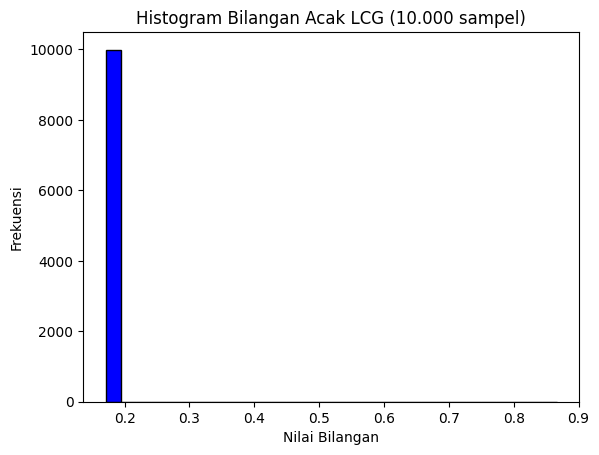

In [ ]:
import matplotlib.pyplot as plt

bil_x, bil_u = pembangkit_lcg(n=10000, seed=1, a=1650, c=3265, m=2**10)

plt.hist(bil_u, bins=30, color='blue', edgecolor='black')
plt.title("Histogram Bilangan Acak LCG (10.000 sampel)")
plt.xlabel("Nilai Bilangan")
plt.ylabel("Frekuensi")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

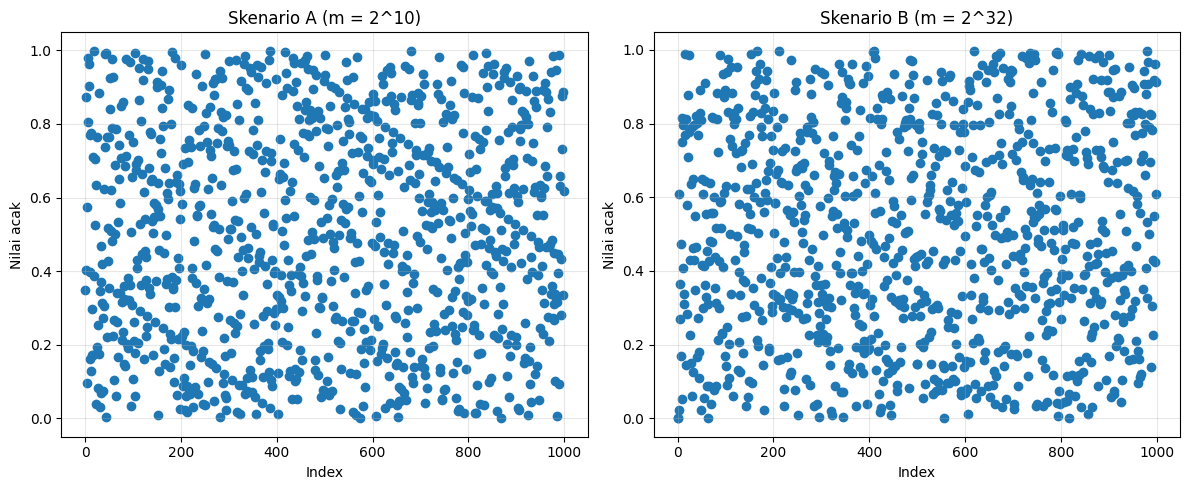

In [ ]:
import matplotlib.pyplot as plt

#Skenario A
bil_x_A,bil_u_A = pembangkit_lcg(n=1000, seed=1, a=165, c=3265, m=2**10)

#Skenario B
bil_x_B,bil_u_B = pembangkit_lcg(n=1000, seed=1, a=165, c=3265, m=2**32)

#plot dalam satu figure
plt.figure(figsize=(12,5))

#subplot 1 (Skenario A)
plt.subplot(1,2,1)
plt.scatter(range(len(bil_u_A)),bil_u_A)
plt.title("Skenario A (m = 2^10)")
plt.xlabel("Index")
plt.ylabel("Nilai acak")
plt.grid(alpha=0.3)

#subplot 2 (Skenario B)
plt.subplot(1,2,2)
plt.scatter(range(len(bil_u_B)),bil_u_B)
plt.title("Skenario B (m = 2^32)")
plt.xlabel("Index")
plt.ylabel("Nilai acak")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show

**Monte Carlo dan Standart Error**

In [ ]:
import numpy as np

np.random.seed(42)
def f(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

def estimasi_mc(n, a, b):
    x_acak = np.random.uniform(a, b, n)
    gx = f(x_acak)
    rata_rata = np.mean(gx)
    estimasi = (b - a) * rata_rata
    return estimasi

a, b = 0, 1.5

# a) n = 100
hasil_a = estimasi_mc(100, a, b)
print("n = 100      :", hasil_a)

# b) n = 10.000
hasil_b = estimasi_mc(10000, a, b)
print("n = 10.000   :", hasil_b)

# c) n = 1.000.000
hasil_c = estimasi_mc(1000000, a, b)
print("n = 1.000.000:", hasil_c)

n = 100      : 0.4450607126611266
n = 10.000   : 0.43575558495997724
n = 1.000.000: 0.433031954004761


In [ ]:
from scipy.stats import norm

eksak = norm.cdf(1.5) - norm.cdf(0)
print(eksak)

0.4331927987311419


In [ ]:
import numpy as np

# fungsi f(x)
def f(x):
    return (1/np.sqrt(2*np.pi)) * np.exp(-0.5*x**2)

# fungsi untuk menghitung standard error
def standard_error(n):
    a, b = 0, 1.5

    # generate sampel acak
    x = np.random.uniform(a, b, n)

    # hitung g(x)
    gx = f(x)

    # hitung standard error
    se = (np.std(gx) * (b - a)) / np.sqrt(n)

    return se

# uji untuk beberapa n
print("SE n=100      :", standard_error(100))
print("SE n=10.000   :", standard_error(10000))
print("SE n=1.000.000:", standard_error(1000000))

SE n=100      : 0.013681129693625818
SE n=10.000   : 0.0012950650707253739
SE n=1.000.000: 0.0001293030798268347


**Acceptance-Rejection**

In [ ]:
import numpy as np

def f(x):
    return (x**2 * (1 - x)**2) + (0.2 * np.exp(-50 * (x - 0.8)**2))

In [ ]:
from scipy.optimize import minimize_scalar

# Fungsi mencari nilai M otomatis
def cari_nilai_m(fungsi_target, a, b):

    hasil_optimasi = minimize_scalar(lambda x: -fungsi_target(x), bounds=(a, b), method='bounded')

    m_minimal = fungsi_target(hasil_optimasi.x)

    return m_minimal

In [ ]:
# Fungsi Acceptance-Rejection
def acceptance_rejection_sampling(n_sampling, f_target, a, b, M):

    samples = []

    total_iterasi = 0

    while len(samples) < n_sampling:

        total_iterasi += 1

        # Kandidat dari proposal Uniform
        y_kandidat = np.random.uniform(a, b)

        # Bilangan acak uniform
        u = np.random.uniform(0, 1)

        # Evaluasi fungsi target
        f_y = f_target(y_kandidat)

        # Proposal Uniform
        mg_y = M * (1 / (b - a))

        # Seleksi diterima / ditolak
        if u <= f_y / mg_y:
            samples.append(y_kandidat)

    return np.array(samples), total_iterasi

In [ ]:
# Parameter
n = 1000
a = 0
b = 1

# Cari M otomatis
m_val = cari_nilai_m(f, a, b)

# Tambah buffer kecil
M1 = m_val + 0.01

# Sampling
data1, iterasi1 = acceptance_rejection_sampling(n, f, a, b, M1)

print("M otomatis =", M1)
print("Jumlah iterasi =", iterasi1)

M otomatis = 0.23652639768168218
Jumlah iterasi = 2957


In [ ]:
M2 = 10

data2, iterasi2 = acceptance_rejection_sampling(n, f, a, b, M2)

print("M manual =", M2)
print("Jumlah iterasi =", iterasi2)

M manual = 10
Jumlah iterasi = 119952


In [ ]:
# Acceptance Rate Skenario 1
AR1 = len(data1) / iterasi1

# Acceptance Rate Skenario 2
AR2 = len(data2) / iterasi2

print("Acceptance Rate Skenario 1 =", AR1)
print("Acceptance Rate Skenario 2 =", AR2)

Acceptance Rate Skenario 1 = 0.3381805884342239
Acceptance Rate Skenario 2 = 0.008336668000533547


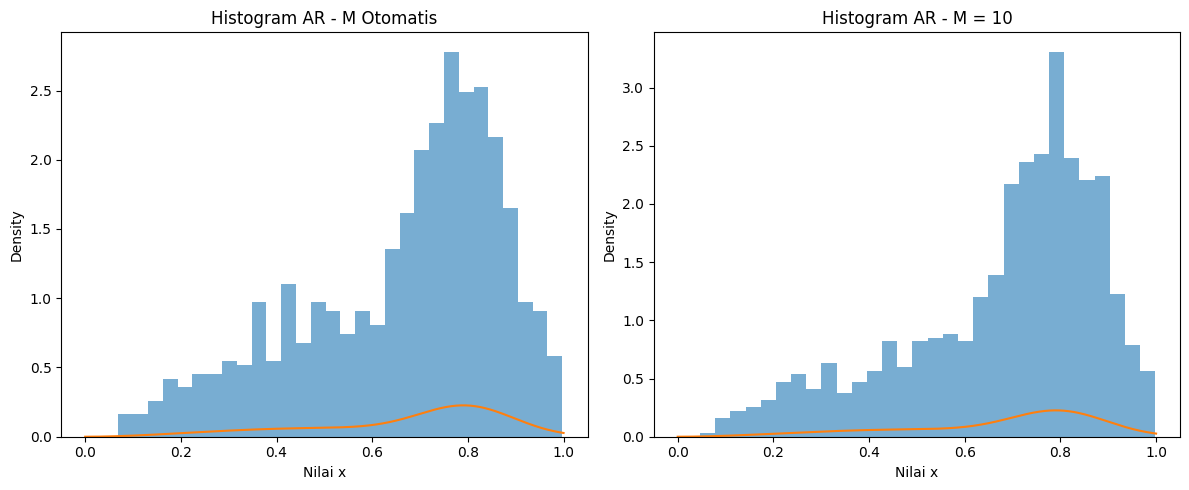

In [ ]:
import matplotlib.pyplot as plt

# Membuat titik x untuk kurva target
x = np.linspace(0, 1, 500)

# Fungsi target
y = f(x)

# ===== Histogram Skenario 1 =====
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

# Histogram sampel hasil acceptance rejection
plt.hist(
    data1,
    bins=30,
    density=True,
    alpha=0.6
)

# Kurva target
plt.plot(x, y)

plt.title("Histogram AR - M Otomatis")
plt.xlabel("Nilai x")
plt.ylabel("Density")

# ===== Histogram Skenario 2 =====
plt.subplot(1,2,2)

plt.hist(
    data2,
    bins=30,
    density=True,
    alpha=0.6
)

plt.plot(x, y)

plt.title("Histogram AR - M = 10")
plt.xlabel("Nilai x")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

**Analisis**

Histogram pada kedua skenario menunjukkan bahwa sampel yang dibangkitkan berhasil mengikuti bentuk fungsi target bimodal karena pola histogram menyerupai kurva distribusi asli.

Pada skenario pertama dengan nilai M otomatis, proses sampling lebih efisien karena acceptance rate lebih tinggi dan jumlah sampel yang ditolak lebih sedikit. Hal ini membuat histogram lebih cepat terbentuk mengikuti distribusi target.

Sedangkan pada skenario kedua dengan M=10, acceptance rate menjadi lebih rendah karena nilai M terlalu besar sehingga banyak kandidat sampel ditolak. Akibatnya, proses pembangkitan sampel membutuhkan iterasi lebih banyak dan komputasi menjadi lebih lambat, meskipun bentuk histogram tetap mengikuti fungsi target.

**Gibbs Sampler**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gibbs_sampler_bivariate(n_interations, rho):
  # 1. Parameter & Inisialisasi
  # Standar deviasi kondisional: sqrt(1 - rho^2)
  sd_cond = np.sqrt(1 - rho**2)
  # Nilai awal (Inisialisasi)
  curr_y = 0

  # 2. Menampung data (Matriks N x 2)
  samples = np.zeros((n_interations, 2))

  # 3. Membuat perulangan
  for i in range (n_interations):
    # 4. Menghitung/Sampling variabel secara bergantian
    # Update X Berdasarkan Y lama
    lambda_x = curr_y + 1
    curr_x = np.random.exponential(scale=1/lambda_x)
    # Update Y Berdasarkan X lama
    lambda_y = curr_x + 1
    curr_y = np.random.exponential(scale=1/lambda_y)
    # 5. Memperbarui wadah data
    samples[i, 0] = curr_x
    samples[i, 1] = curr_y

# 6. Mengeluarkan hasil
  return samples

In [ ]:
# Eksekusi dengan korelasi 0.8
n = 10000
rho_val = 0.8
hasil_gibbs = gibbs_sampler_bivariate(n, rho_val)
print(f"Jumlah sampel yang berhasil dibangkitkan: {len(hasil_gibbs)}")

Jumlah sampel yang berhasil dibangkitkan: 10000


In [ ]:
# Melakukan Burn-in dengan membuang 1000 data pertama
data_after_burnin = hasil_gibbs[1000:]
print(data_after_burnin)

[[0.57035484 0.17129359]
 [0.7011001  0.31068628]
 [1.18356488 0.17111441]
 ...
 [1.28245672 0.22619913]
 [0.31852211 0.82405282]
 [2.96494664 0.12585058]]


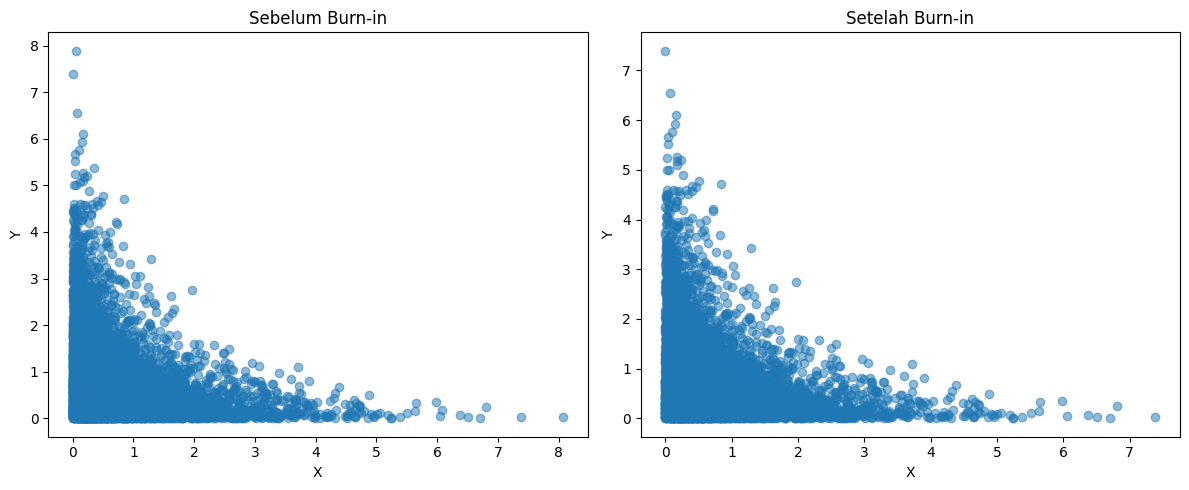

In [ ]:
import matplotlib.pyplot as plt
# Data sebelum burn-in
x_all = hasil_gibbs[:, 0]
y_all = hasil_gibbs[:, 1]

# Data setelah burn-in
x_burn = data_after_burnin[:, 0]
y_burn = data_after_burnin[:, 1]

# Buat 1 figure dengan 2 subplot (kiri-kanan)
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Plot kiri: sebelum burn-in
ax[0].scatter(x_all, y_all, alpha=0.5)
ax[0].set_title("Sebelum Burn-in")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")

# Plot kanan: setelah burn-in
ax[1].scatter(x_burn, y_burn, alpha=0.5)
ax[1].set_title("Setelah Burn-in")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Y")

plt.tight_layout()
plt.show()

**Jaque Bera**

In [ ]:
data = [12,15,14,10,18,16,13,17,11,14]

n = len(data)

mean = sum(data) / n

selisih = []
for x in data:
    selisih.append(x - mean)

m2 = 0
for d in selisih:
    m2 += d**2

m2 = m2 / n

m3 = 0
for d in selisih:
    m3 += d**3

m3 = m3 / n

m4 = 0
for d in selisih:
  m4 += d**4

m4 = m4 / n

skewness = m3 / (m2**1.5)
kurtosis = m4 / (m2**2)

jb = (n / 6) * (skewness**2 + ((kurtosis - 3)**2) / 4)

chi_square_critical = 5.991

if jb > chi_square_critical:
    keputusan = "Tolak H0: data tidak berdistribusi normal"
else:
    keputusan = "Gagal menolak H0: data berdistribusi normal"

print(f"JB Statistic: {jb:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")
print(f"Decision: {keputusan}")

JB Statistic: 0.4449
Skewness: 0.0000
Kurtosis: 1.9667
Decision: Gagal menolak H0: data berdistribusi normal


**Jaque Bera (Test)**

In [ ]:
def jarque_bera_test(data):

    # jumlah data
    n = len(data)

    # mean
    mean = sum(data) / n

    # momen
    m2 = sum((x - mean)**2 for x in data) / n
    m3 = sum((x - mean)**3 for x in data) / n
    m4 = sum((x - mean)**4 for x in data) / n

    # skewness
    skewness = m3 / (m2 ** 1.5)

    # kurtosis
    kurtosis = m4 / (m2 ** 2)

    # Jarque-Bera
    jb = (n / 6) * (skewness**2 + ((kurtosis - 3)**2) / 4)

    # keputusan
    chi_square_critical = 5.991

    if jb < chi_square_critical:
        keputusan = ("Gagal menolak H0: data berdistribusi normal")
    else:
        keputusan = ("Tolak H0: data tidak berdistribusi normal")

    # output seluruh nilai
    print("n =", n)
    print("mean =", mean)
    print("m2 =", m2)
    print("m3 =", m3)
    print("m4 =", m4)
    print("skewness =", skewness)
    print("kurtosis =", kurtosis)
    print("JB =", jb)
    print(keputusan)

### Asal `chi_square_critical = 5.991`

Nilai `chi_square_critical = 5.991` berasal dari tabel distribusi chi-kuadrat. Ini adalah nilai kritis untuk:

- **Tingkat Signifikansi (alpha):** 0.05
- **Derajat Kebebasan (df):** 2

Dalam konteks uji Jarque-Bera, derajat kebebasan selalu 2 karena uji ini menguji dua karakteristik distribusi: skewness (kemencengan) dan kurtosis (keruncingan).

In [ ]:
from scipy.stats import chi2

alpha = 0.05  # Tingkat signifikansi
df = 2        # Derajat kebebasan untuk uji Jarque-Bera

chi_square_critical_calculated = chi2.ppf(1 - alpha, df)

print(f"Tingkat Signifikansi (alpha): {alpha}")
print(f"Derajat Kebebasan (df): {df}")
print(f"Nilai Kritis Chi-Square: {chi_square_critical_calculated:.3f}")

In [ ]:
data = [12,15,14,10,18,16,13,17,11,14]
jarque_bera_test(data)

n = 10
mean = 14.0
m2 = 6.0
m3 = 0.0
m4 = 70.8
skewness = 0.0
kurtosis = 1.9666666666666666
JB = 0.4449074074074075
Gagal menolak H0: data berdistribusi normal


**Uji Normalitas Kolmologrov Smirnov**

**pengertian**

Uji Kolmogorov-Smirnov (K-S) adalah metode statistik untuk menguji apakah suatu sampel berasal dari distribusi tertentu, biasanya distribusi normal.

Prinsipnya adalah membandingkan:

1. Distribusi kumulatif empiris data (ECDF)

2. Distribusi kumulatif teoritis normal (CDF)

Semakin kecil perbedaannya, semakin dekat data terhadap distribusi normal.

**Rumus**

**Distribusi Kumulatif Empiris**

F
n
	​
(x)=
n
i
	​


dimana:

i = urutan data

n = jumlah data

**Distribusi Normal Teoritis**

F(x)=Φ(z)

dengan

z=
σ
x−μ
	​

**Statistik K-S**

D=max∣F
n
(x)−F(x)∣

Nilai D terbesar digunakan sebagai statistik pengujian.

In [ ]:
import math

def kolmogorov_smirnov_test(data):

    n = len(data)

    #Urutkan Data
    sorted_data = sorted(data)

    #Menghitung Mean
    mean = sum(data)/len(data)

    #Hitung Standart Deviasi
    variance = sum((x-mean)**2 for x in data)/len(data)
    std = variance**0.5

    D = 0.0

    D_kritis = 1.36 / math.sqrt(n)

    for i, x_val in enumerate(sorted_data, start=1):

        # Hitung Z-Score
        z = (x_val - mean) / std

        # Hitung CDF Normal
        cdf = 0.5 * (1 + math.erf(z / math.sqrt(2)))

        # Hitung ECDF
        ecdf = i / n

        # Hitung selisih absolut
        diff = abs(ecdf - cdf)

        # Cari nilai D maksimum
        D = max(D, diff)

    print("\nD Hitung =", round(D,4))
    print("D Kritis =", round(D_kritis,4))

    if D < D_kritis:
        Keputusan: ("Gagal menolak H0: data berdistribusi normal")
    else:
        Keputusan: ("Tolak H0: data tidak berdistribusi normal")
    print(keputusan)

In [ ]:
data = [12,15,14,10,18,16,13,17,11,14]
kolmogorov_smirnov_test(data)


D Hitung = 0.1
D Kritis = 0.4301
Gagal menolak H0: data berdistribusi normal


**Uji Homogenitas**

In [ ]:
def uji_F_varians(data1, data2, alpha=0.05):

  n1 = len(data1)
  n2 = len(data2)

  mean1 = sum(data1) / n1
  mean2 = sum(data2) / n2

  jumlah_kuadrat1 = 0
  for x in data1:
    jumlah_kuadrat1 += (x - mean1) ** 2
  varians1 = jumlah_kuadrat1 / (n1 - 1)

  jumlah_kuadrat2 = 0
  for x in data2:
    jumlah_kuadrat2 += (x - mean2) ** 2
  varians2 = jumlah_kuadrat2 / (n2 - 1)

  if varians1 > varians2:
    f_hitung = varians1 / varians2
    df1 = n1 - 1
    df2 = n2 - 1
  else:
    f_hitung = varians2 / varians1
    df1 = n2 - 1
    df2 = n1 - 1

  import scipy.stats as stats
  f_tabel = stats.f.ppf(1 - alpha, df1, df2)

  if f_hitung < f_tabel:
    keputusan = ("Gagal menolak H0: Varians Homogen")
  else:
    keputusan = ("Tolak H0: Varians tidak Homogen")

  print("n1 =", n1)
  print("n2 =", n2)
  print("mean1 =", mean1)
  print("mean2 =", mean2)
  print("Varians 1 =", varians1)
  print("Varians 2 =", varians2)
  print("F Hitung =", f_hitung)
  print("F Tabel =", f_tabel)
  print(keputusan)

In [ ]:
data1 = [70, 75, 80, 72, 78]
data2 = [65, 85, 60, 90, 70]
uji_F_varians(data1, data2)

n1 = 5
n2 = 5
mean1 = 75.0
mean2 = 74.0
Varians 1 = 17.0
Varians 2 = 167.5
F Hitung = 9.852941176470589
F Tabel = 6.388232908695868
Tolak H0: Varians tidak Homogen


**Uji Levane**

**pengertian**

Uji Levene digunakan untuk menguji kesamaan varians dari dua atau lebih kelompok data.

Keunggulan Levene dibanding Uji F adalah:

1. Lebih robust terhadap data yang tidak normal.
2. Sering digunakan sebelum ANOVA.

Hipotesis:

1. H₀ : Varians seluruh kelompok sama (homogen).
2. H₁ : Minimal ada satu varians yang berbeda.

**Rumus**

**Hitung Deviasi Absolut**

Zij = ∣Xij − Xˉi∣

dimana:

Xij = data ke-j kelompok ke-i

Xˉi = rata-rata kelompok ke-i

**Statistik Levane**

W= (N−k) / k − 1 × ∑ni(Zˉi−Zˉ)2 / ∑∑ (Zij−Zˉi)2

Keterangan:

N = jumlah seluruh data

k = jumlah kelompok

ni = ukuran kelompok

Zˉi = rata-rata deviasi kelompok

Zˉ = rata-rata deviasi total

In [ ]:
from scipy.stats import f

data1 = [70,75,80,72,78]
data2 = [65,85,60,90,70]

#Hitung Mean
mean1 = sum(data1)/len(data1)
mean2 = sum(data2)/len(data2)

#Hitung Deviasi Absolut
z1 = [abs(x - mean1) for x in data1]
z2 = [abs(x - mean2) for x in data2]

#Hitung Rata - Rata Deviasi
zbar1 = sum(z1)/len(z1)
zbar2 = sum(z2)/len(z2)

#Hitung Rata - Rata Gabungan
all_z = z1 + z2
zbar = sum(all_z)/len(all_z)

#Hitung Pembilang
numerator = (
len(z1)*(zbar1-zbar)**2 +
len(z2)*(zbar2-zbar)**2
)

#Hitung Penyebut
denominator = (
sum((z-zbar1)**2 for z in z1) +
sum((z-zbar2)**2 for z in z2)
)
# Hitung Statistik Levene
N = len(data1) + len(data2)
k = 2

W = ((N - k) / (k - 1)) * (numerator / denominator)

alpha = 0.05
df1 = (k - 1)
df2 = (N - k)

F_tabel = f.ppf(1 - alpha, df1, df2)

print("F_tabel =", F_tabel)

# Keputusan
if W < F_tabel:
    keputusan = "Gagal menolak H0: Varians Homogen"
else:
    keputusan = "Tolak H0: Varians tidak Homogen"

print("mean1 =", mean1)
print("mean2 =", mean2)
print("z1 =", z1)
print("z2 =", z2)
print("zbar1 =", zbar1)
print("zbar2 =", zbar2)
print("zbar =", zbar)
print("numerator =", numerator)
print("denominator =", denominator)
print("W =", W)
print("F_tabel =", F_tabel)
print(keputusan)

F_tabel = 5.317655071578714
mean1 = 75.0
mean2 = 74.0
z1 = [5.0, 0.0, 5.0, 3.0, 3.0]
z2 = [9.0, 11.0, 14.0, 16.0, 4.0]
zbar1 = 3.2
zbar2 = 10.8
zbar = 7.0
numerator = 144.40000000000003
denominator = 103.6
W = 11.150579150579153
F_tabel = 5.317655071578714
Tolak H0: Varians tidak Homogen


**Uji Independensi Chi-Squere**

In [ ]:
def uji_chi_square(data, alpha=0.05):

  jumlah_baris = len(data)
  jumlah_kolom = len(data[0])

  total_baris = []
  for baris_data in data:
        total_baris.append(sum(baris_data))

  total_kolom = []
  for j in range (jumlah_kolom):
    total = 0
    for i in range (jumlah_baris):
      total += data[i][j]
    total_kolom.append(total)

  grand_total = sum(total_baris)

  harapan = []
  for i in range (jumlah_baris):
    baris = []
    for j in range (jumlah_kolom):
      eij = (total_baris[i] * total_kolom[j] / grand_total)
      baris.append(eij)
    harapan.append(baris)

  chi_square = 0
  for i in range (jumlah_baris):
    for j in range (jumlah_kolom):
      O = data[i][j]
      E = harapan[i][j]
      chi_square += ((O - E)**2) / E

  df = ((jumlah_baris - 1) * (jumlah_kolom - 1))

  from scipy.stats import chi2
  chi_tabel = chi2.ppf(1 - alpha,df)

  if chi_square > chi_tabel:
    keputusan = ("Gagal menolak H0: Terdapat Hubungan")
  else:
    keputusan = ("Tolak H0: Tidak Terdapat Hubungan")

  print("jumlah_baris =", jumlah_baris)
  print("jumlah_kolom =", jumlah_kolom)
  print("grand_total =", grand_total)
  print("harapan =", harapan)
  print("chi_square =", chi_square)
  print("chi_tabel =", chi_tabel)
  print(keputusan)

In [ ]:
data = [[30,20],[15,35]]
uji_chi_square(data)

jumlah_baris = 2
jumlah_kolom = 2
grand_total = 100
harapan = [[22.5, 27.5], [22.5, 27.5]]
chi_square = 9.09090909090909
chi_tabel = 3.841458820694124
Tolak H0: Terdapat Hubungan


**Fisher's Exact Test**

**Pengertian**

Fisher's Exact Test adalah uji statistik yang digunakan untuk menguji hubungan (independensi) antara dua variabel kategorik pada tabel kontingensi 2×2.

Uji ini sangat cocok digunakan apabila:

1. ukuran sampel kecil.
2. terdapat frekuensi harapan kurang dari 5.
3. hasil Chi-Square kurang akurat.

In [ ]:
#MENGGUNAKAN LIBRARY
from scipy.stats import fisher_exact

data = [[30, 20],[15, 35]]

odds_ratio, p_value = fisher_exact(data)

alpha = 0.05

if p_value < alpha:
    keputusan = "Gagal menolak H0: Terdapat Hubungan"
else:
    keputusan = "Tolak H0: Tidak Terdapat Hubungan"

print("data =", data)
print("odds_ratio =", odds_ratio)
print("p_value =", p_value)
print(keputusan)

data = [[30, 20], [15, 35]]
odds_ratio = 3.5
p_value = 0.004635020180798911
Gagal menolak H0: Terdapat Hubungan


In [ ]:
#TANPA LIBRARY STATISTIK
def faktorial(x):
    hasil = 1
    for i in range(1, x + 1):
        hasil *= i
    return hasil


data = [[30,20],[15,35]]

a = data[0][0]
b = data[0][1]
c = data[1][0]
d = data[1][1]

row1 = a + b
row2 = c + d

col1 = a + c
col2 = b + d

n = row1 + row2

P = (
    faktorial(row1)
    * faktorial(row2)
    * faktorial(col1)
    * faktorial(col2)
) / (
    faktorial(a)
    * faktorial(b)
    * faktorial(c)
    * faktorial(d)
    * faktorial(n)
)

alpha = 0.05

if P < alpha:
    keputusan = "Gagal menolak H0: Terdapat Hubungan"
else:
    keputusan = "Tolak H0: Tidak Terdapat Hubungan"

print("P =", P)
print(keputusan)

P = 0.0017263216264753742
Gagal menolak H0: Terdapat Hubungan
